In [18]:
import numpy as np

def harmonic_interpolation(
    deg_obs,
    y_obs,
    deg_out,
    n_harmonics=5,
    ridge=1e-6
):
    """
    不等間隔に観測された1周期のデータを、
    調和回帰でなめらかに補間して返す関数。

    想定しているデータ
    ------------------
    横軸 : カム角度 [deg]
           0～360度で1周期とみなす
    縦軸 : センサ値

    この関数がやっていること
    ------------------------
    次の式を観測データに当てはめる。

        y(θ) = a0
             + a1*cos(1*θ) + b1*sin(1*θ)
             + a2*cos(2*θ) + b2*sin(2*θ)
             + ...
             + aK*cos(K*θ) + bK*sin(K*θ)

    ここで K = n_harmonics です。

    つまり、
    「周期的な波を何個か足し合わせて、元の波形を表す」
    という考え方です。

    Parameters
    ----------
    deg_obs : array-like
        観測したカム角度 [deg]
        不等間隔でよい
    y_obs : array-like
        観測したセンサ値
    deg_out : array-like
        補間後の値を出したい角度 [deg]
        例: np.linspace(0, 360, 361)
    n_harmonics : int, default=5
        何次までの調和成分を使うか
        小さいほどなめらか、大きいほど細かい形まで表せる
    ridge : float, default=1e-6
        解を少し安定化するための小さい値
        大きくしすぎると波形がなまりやすい

    Returns
    -------
    y_out : ndarray
        deg_out に対応する補間結果
    """

    # -----------------------------
    # 1) 入力を numpy 配列に変換する
    # -----------------------------
    # reshape(-1) にして、1次元ベクトルにそろえる
    deg_obs = np.asarray(deg_obs, dtype=float).reshape(-1)
    y_obs = np.asarray(y_obs, dtype=float).reshape(-1)
    deg_out = np.asarray(deg_out, dtype=float).reshape(-1)

    # -----------------------------
    # 2) 入力チェック
    # -----------------------------
    if len(deg_obs) != len(y_obs):
        raise ValueError("deg_obs と y_obs の長さが一致していません。")

    if len(deg_obs) == 0:
        raise ValueError("deg_obs と y_obs が空です。")

    if n_harmonics < 1:
        raise ValueError("n_harmonics は 1 以上にしてください。")

    # -----------------------------
    # 3) NaN や inf を除去する
    # -----------------------------
    # センサ値や角度に欠損や異常値が混ざることがあるので、
    # 有効なデータだけを残す
    valid = np.isfinite(deg_obs) & np.isfinite(y_obs)
    deg_obs = deg_obs[valid]
    y_obs = y_obs[valid]

    if len(deg_obs) == 0:
        raise ValueError("有効な観測データがありません。")

    # -----------------------------
    # 4) 角度を [0, 360) にそろえる
    # -----------------------------
    # たとえば 370度 -> 10度, -20度 -> 340度 に直す
    # 周期データとして扱うため
    deg_obs = np.mod(deg_obs, 360.0)
    deg_out = np.mod(deg_out, 360.0)

    # -----------------------------
    # 5) 度をラジアンに変換する
    # -----------------------------
    # numpy の sin, cos はラジアンで計算するため
    theta_obs = np.deg2rad(deg_obs)
    theta_out = np.deg2rad(deg_out)

    # -----------------------------
    # 6) 設計行列を作るための小関数
    # -----------------------------
    def make_design_matrix(theta, n_harmonics):
        """
        調和回帰の説明変数行列を作る関数。

        返す行列 X の各列は次の順番：
        [1, cos(1θ), sin(1θ), cos(2θ), sin(2θ), ..., cos(Kθ), sin(Kθ)]

        たとえば K=2 のとき列数は 1 + 2*2 = 5 本になる。
        """
        # 行数 = データ点数
        n = len(theta)

        # 列数 = 定数項1本 + 各次数につき cos と sin で2本ずつ
        n_cols = 1 + 2 * n_harmonics

        # まず空の行列を作る
        X = np.zeros((n, n_cols), dtype=float)

        # 1列目は定数項
        X[:, 0] = 1.0

        # 2列目以降に cos(kθ), sin(kθ) を順に入れる
        col = 1
        for k in range(1, n_harmonics + 1):
            X[:, col] = np.cos(k * theta)
            X[:, col + 1] = np.sin(k * theta)
            col += 2

        return X

    # 観測点用の設計行列
    X_obs = make_design_matrix(theta_obs, n_harmonics)

    # 出力したい角度用の設計行列
    X_out = make_design_matrix(theta_out, n_harmonics)

    # -----------------------------
    # 7) 最小二乗法で係数を求める
    # -----------------------------
    # 通常は
    #   coef = argmin ||X_obs @ coef - y_obs||^2
    # を解く。
    #
    # ただし数値的に少し不安定になることがあるので、
    # ridge * I を足して安定化する。
    #
    #   (X^T X + ridge*I) coef = X^T y
    #
    # を解く形にしている。
    #
    # 定数項まで強く縮めたくないので、
    # 1列目（切片）の正則化だけは 0 にする。
    XtX = X_obs.T @ X_obs
    Xty = X_obs.T @ y_obs

    regularization = ridge * np.eye(XtX.shape[0], dtype=float)
    regularization[0, 0] = 0.0  # 定数項は縮めない

    coef = np.linalg.solve(XtX + regularization, Xty)

    # -----------------------------
    # 8) 補間結果を計算して返す
    # -----------------------------
    y_out = X_out @ coef
    return y_out

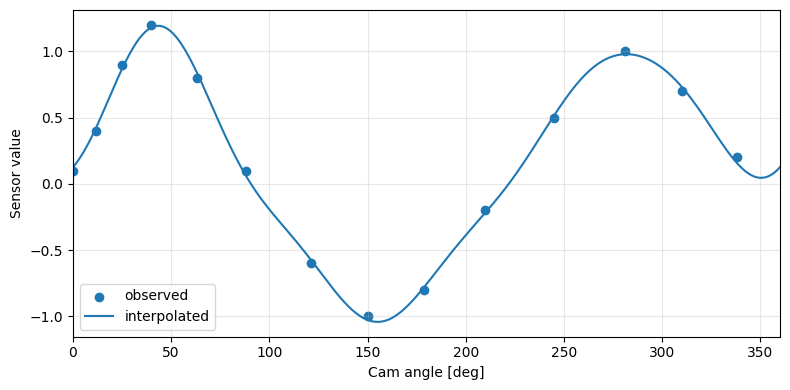

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 不等間隔の観測点
deg_obs = np.array([0, 12, 25, 40, 63, 88, 121, 150, 179, 210, 245, 281, 310, 338], dtype=float)
y_obs = np.array([0.1, 0.4, 0.9, 1.2, 0.8, 0.1, -0.6, -1.0, -0.8, -0.2, 0.5, 1.0, 0.7, 0.2], dtype=float)

# 補間後に出したい角度
deg_out = np.linspace(0, 360, 361)

# 補間
y_out = harmonic_interpolation(
    deg_obs=deg_obs,
    y_obs=y_obs,
    deg_out=deg_out,
    n_harmonics=5
)

# 可視化
plt.figure(figsize=(8, 4))
plt.scatter(deg_obs, y_obs, label="observed")
plt.plot(deg_out, y_out, label="interpolated")
plt.xlim(0, 360)
plt.xlabel("Cam angle [deg]")
plt.ylabel("Sensor value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

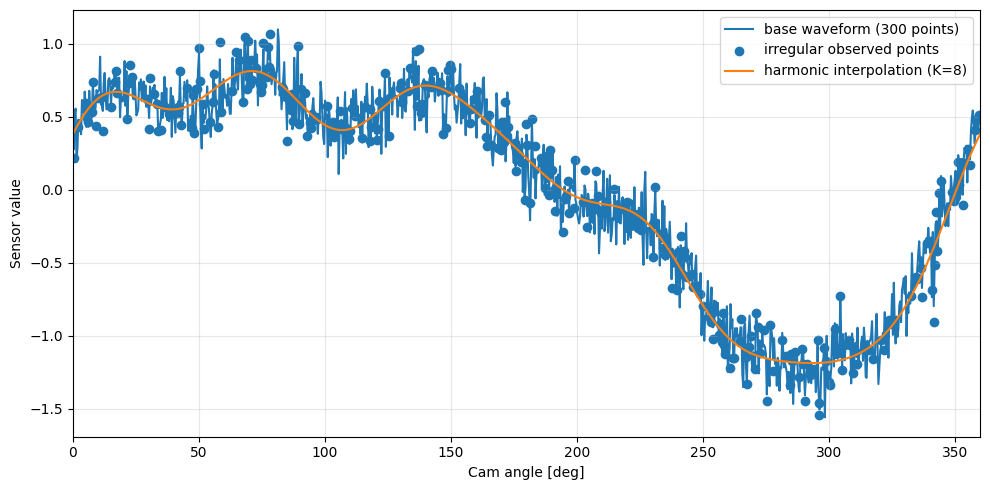

=== Summary ===
Base waveform points        : 1000
Irregular observed points   : 300
Output points               : 361
n_harmonics                 : 8
RMSE vs base waveform       : 0.107617
Average time per call [ms]  : 0.250462

=== Timing by n_harmonics ===
K= 3 : 0.110757 ms/call
K= 5 : 0.159385 ms/call
K= 8 : 0.237206 ms/call
K=12 : 0.545621 ms/call
K=20 : 1.323096 ms/call

Saved plot  : \mnt\data\harmonic_interpolation_demo.png
Saved script: \mnt\data\harmonic_interpolation_demo.py


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

# ============================================================
# 1) 調和回帰で補間する関数
#    前の会話で出したものを、そのまま使える形で再掲
# ============================================================
def harmonic_interpolation(
    deg_obs,
    y_obs,
    deg_out,
    n_harmonics=5,
    ridge=1e-6
):
    """
    不等間隔に観測された1周期データを、
    調和回帰でなめらかに補間して返す関数。

    Parameters
    ----------
    deg_obs : array-like
        観測角度 [deg]
    y_obs : array-like
        観測値
    deg_out : array-like
        補間後の値を出したい角度 [deg]
    n_harmonics : int
        調和次数
    ridge : float
        解を安定化するための小さな正則化項

    Returns
    -------
    y_out : ndarray
        deg_out に対応する補間結果
    """
    deg_obs = np.asarray(deg_obs, dtype=float).reshape(-1)
    y_obs = np.asarray(y_obs, dtype=float).reshape(-1)
    deg_out = np.asarray(deg_out, dtype=float).reshape(-1)

    if len(deg_obs) != len(y_obs):
        raise ValueError("deg_obs と y_obs の長さが一致していません。")
    if len(deg_obs) == 0:
        raise ValueError("deg_obs と y_obs が空です。")
    if n_harmonics < 1:
        raise ValueError("n_harmonics は 1 以上にしてください。")

    # NaN / inf を除去
    valid = np.isfinite(deg_obs) & np.isfinite(y_obs)
    deg_obs = deg_obs[valid]
    y_obs = y_obs[valid]

    if len(deg_obs) == 0:
        raise ValueError("有効な観測データがありません。")

    # 周期データとして [0, 360) にそろえる
    deg_obs = np.mod(deg_obs, 360.0)
    deg_out = np.mod(deg_out, 360.0)

    theta_obs = np.deg2rad(deg_obs)
    theta_out = np.deg2rad(deg_out)

    def make_design_matrix(theta, n_harmonics):
        """
        調和回帰の設計行列を作る。
        列の並び:
        [1, cos(1θ), sin(1θ), cos(2θ), sin(2θ), ..., cos(Kθ), sin(Kθ)]
        """
        n = len(theta)
        n_cols = 1 + 2 * n_harmonics
        X = np.zeros((n, n_cols), dtype=float)
        X[:, 0] = 1.0

        col = 1
        for k in range(1, n_harmonics + 1):
            X[:, col] = np.cos(k * theta)
            X[:, col + 1] = np.sin(k * theta)
            col += 2
        return X

    X_obs = make_design_matrix(theta_obs, n_harmonics)
    X_out = make_design_matrix(theta_out, n_harmonics)

    XtX = X_obs.T @ X_obs
    Xty = X_obs.T @ y_obs

    regularization = ridge * np.eye(XtX.shape[0], dtype=float)
    regularization[0, 0] = 0.0  # 定数項は縮めない

    coef = np.linalg.solve(XtX + regularization, Xty)
    y_out = X_out @ coef
    return y_out


# ============================================================
# 2) 1周期300点の「少し複雑な基準波形」を作る
#    現場っぽく、基本波 + 局所的な山谷 + 軽いノイズ
# ============================================================
rng = np.random.default_rng(42)

n_base = 1000
deg_base = np.linspace(0.0, 360.0, n_base, endpoint=False)
theta = np.deg2rad(deg_base)

# 複雑さを持たせた基準波形
# - 基本の周期成分
# - 2次, 3次, 5次の成分
# - 局所的な山
# - 軽いセンサノイズ
y_base_clean = (
    0.85 * np.sin(theta - 0.2)
    + 0.40 * np.sin(2 * theta + 0.9)
    + 0.18 * np.cos(3 * theta - 0.4)
    + 0.10 * np.sin(5 * theta + 1.2)
)

# 局所形状の追加（ガウス状の盛り上がり）
def circular_gaussian(deg, center_deg, sigma_deg):
    d = np.abs((deg - center_deg + 180.0) % 360.0 - 180.0)
    return np.exp(-0.5 * (d / sigma_deg) ** 2)

y_base_clean = (
    y_base_clean
    + 0.30 * circular_gaussian(deg_base, 75.0, 10.0)
    - 0.22 * circular_gaussian(deg_base, 210.0, 14.0)
    + 0.16 * circular_gaussian(deg_base, 310.0, 8.0)
)

# 基準波形に軽いノイズを追加
y_base = y_base_clean + 0.13 * rng.standard_normal(n_base)

# ============================================================
# 3) 基準波形から不等間隔観測データを作る
#    300点全部ではなく、ランダムな角度だけ観測した想定
# ============================================================
n_obs = 300  # 不等間隔の観測点数
obs_idx = np.sort(rng.choice(n_base, size=n_obs, replace=False))
deg_obs = deg_base[obs_idx]

# 観測値は、基準波形からサンプルしたものに観測ノイズを加える
y_obs = y_base[obs_idx] + 0.05 * rng.standard_normal(n_obs)

# 念のため少し順番を崩してから、関数が問題なく動くことも確認
shuffle_idx = rng.permutation(n_obs)
deg_obs_unsorted = deg_obs[shuffle_idx]
y_obs_unsorted = y_obs[shuffle_idx]

# 出力角度
deg_out = np.linspace(0.0, 360.0, 361)

# ============================================================
# 4) 補間を実行
# ============================================================
n_harmonics = 8
y_out = harmonic_interpolation(
    deg_obs=deg_obs_unsorted,
    y_obs=y_obs_unsorted,
    deg_out=deg_out,
    n_harmonics=n_harmonics,
    ridge=1e-6
)

# 比較用に、基準波形を deg_out に線形補間
# （誤差確認のためだけに使う。補間関数そのものとは無関係）
deg_base_closed = np.r_[deg_base, 360.0]
y_base_closed = np.r_[y_base, y_base[0]]
y_ref_out = np.interp(deg_out, deg_base_closed, y_base_closed)

rmse = float(np.sqrt(np.mean((y_out - y_ref_out) ** 2)))

# ============================================================
# 5) 計算時間を計測
#    単発時間はぶれやすいので複数回回して平均を取る
# ============================================================
n_repeat = 1000

t0 = time.perf_counter()
for _ in range(n_repeat):
    _ = harmonic_interpolation(
        deg_obs=deg_obs_unsorted,
        y_obs=y_obs_unsorted,
        deg_out=deg_out,
        n_harmonics=n_harmonics,
        ridge=1e-6
    )
t1 = time.perf_counter()

elapsed_total = t1 - t0
elapsed_per_call_ms = (elapsed_total / n_repeat) * 1000.0

# 参考として、調和次数を変えたときの時間も測る
benchmark_rows = []
for K in [3, 5, 8, 12, 20]:
    t0 = time.perf_counter()
    for _ in range(n_repeat):
        _ = harmonic_interpolation(
            deg_obs=deg_obs_unsorted,
            y_obs=y_obs_unsorted,
            deg_out=deg_out,
            n_harmonics=K,
            ridge=1e-6
        )
    t1 = time.perf_counter()
    benchmark_rows.append((K, (t1 - t0) / n_repeat * 1000.0))

# ============================================================
# 6) 図を保存
# ============================================================
out_dir = Path("/mnt/data")
fig_path = out_dir / "harmonic_interpolation_demo.png"
script_path = out_dir / "harmonic_interpolation_demo.py"

plt.figure(figsize=(10, 5))
plt.plot(deg_base, y_base, label="base waveform (300 points)")
plt.scatter(deg_obs_unsorted, y_obs_unsorted, label="irregular observed points")
plt.plot(deg_out, y_out, label=f"harmonic interpolation (K={n_harmonics})")
plt.xlabel("Cam angle [deg]")
plt.ylabel("Sensor value")
plt.xlim(0, 360)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()



print("=== Summary ===")
print(f"Base waveform points        : {n_base}")
print(f"Irregular observed points   : {n_obs}")
print(f"Output points               : {len(deg_out)}")
print(f"n_harmonics                 : {n_harmonics}")
print(f"RMSE vs base waveform       : {rmse:.6f}")
print(f"Average time per call [ms]  : {elapsed_per_call_ms:.6f}")
print()
print("=== Timing by n_harmonics ===")
for K, ms in benchmark_rows:
    print(f"K={K:2d} : {ms:.6f} ms/call")

print()
print(f"Saved plot  : {fig_path}")
print(f"Saved script: {script_path}")